# Preprocessing

This notebook documents the preprocessing stage of the data pipeline.
The goal is to identify distributional issues in the raw dataset, apply targeted preprocessing steps, and verify their effect before proceeding to feature engineering and target construction.

## Basic set up

We begin by loading the raw daily panel dataset and verifying its basic structure, including date coverage, ticker coverage, and key integrity constraints.

### Imports and Paths

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

RAW_PATH = "../data/processed/financial_database.parquet"
OUT_PREP_PATH = "../data/processed/financial_database_preprocessed.parquet"

### Load Data

In [29]:
df_raw = pd.read_parquet(RAW_PATH)

print("Shape:", df_raw.shape)
display(df_raw.head(3))

Shape: (27650, 36)


,date,open,high,low,close,adj_close,volume,sma_50,sma_200,ema_20,price_sma_50,rsi_14,macd,macd_signal,volatility_20d,ret_1d,ret_5d,ret_21d,net_margin,operating_margin,ebitda_margin,asset_turnover,roe,roa,fcf_margin,revenue_growth_qoq,earnings_growth_qoq,fcf_growth_qoq,debt_to_equity,current_ratio,effective_date,macro_effective_date,CPIAUCSL,FEDFUNDS,GDP,ticker
0,2015-01-02,27.847500,27.860001,26.837500,27.332500,24.237553,212818400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.201007,0.265057,0.321819,0.181691,0.075905,0.036521,0.223109,0.125321,0.092798,0.201176,0.316414,1.012057,2014-11-29,2015-01-01,NaN,0.11,NaN,AAPL
1,2015-01-02,15.629000,15.737500,15.348000,15.426000,15.426000,55664000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.021235,-0.026435,0.027455,0.509142,-0.042279,-0.010812,0.018854,0.064064,2.468254,-1.906542,0.383417,0.891085,2014-11-29,2015-01-01,NaN,0.11,NaN,AMZN
2,2015-01-02,26.629999,26.790001,26.393999,26.477501,26.278944,26480000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.165769,0.225383,0.328572,0.131363,0.027718,0.021776,0.216486,0.035600,-0.182632,0.199933,0.053018,4.470703,2014-11-29,2015-01-01,NaN,0.11,NaN,GOOGL


### Structural Cheks

In [30]:
print("Date range:", df_raw["date"].min(), "→", df_raw["date"].max())
print("Tickers:", df_raw["ticker"].nunique(), sorted(df_raw["ticker"].unique())[:20])

dups = df_raw.duplicated(["date", "ticker"]).sum()
print("Duplicati (date,ticker):", dups)

Date range: 2015-01-02 00:00:00 → 2025-12-30 00:00:00
Tickers: 10 ['AAPL', 'AMZN', 'GOOGL', 'JNJ', 'KO', 'META', 'MSFT', 'NVDA', 'TSLA', 'XOM']
Duplicati (date,ticker): 0


The basic checks pass, so we now focus on issues that can bias models or break assumptions if left untreated.

## Exploration of numerical columns

This section provides an exploratory analysis of numerical variables to assess scale, dispersion, and the presence of potential issues such as outliers or structural missing values.
The analysis is used to motivate preprocessing choices rather than to discover predictive patterns.

### Statistics summary

We report summary statistics for numerical features, including percentiles, to identify variables with extreme values, heavy tails, or scale heterogeneity.
These statistics guide the selection of variables requiring stabilization during preprocessing.

In [ ]:
# Divide columns into groups (explicit lists to avoid order assumptions)
price_cols = [c for c in ["open","high","low","close","adj_close","volume"] if c in df_raw.columns]

technical_cols = [
    "sma_200",
    "price_sma_200",
    "mom_3m",
    "mom_6m",
    "mom_12m",
    "volatility_20d",
    "volatility_60d",
    "ret_1d",
    "ret_21d",
]
technical_cols = [c for c in technical_cols if c in df_raw.columns]

fund_cols = [
    "operating_margin",
    "gross_margin",
    "roe",
    "roa",
    "revenue_growth_yoy",
    "earnings_growth_yoy",
    "debt_to_equity",
    "interest_coverage",
    "asset_turnover",
    "fcf_assets",
]
fund_cols = [c for c in fund_cols if c in df_raw.columns]

macro_cols = ["CPIAUCSL", "INDPRO", "DGS10", "DGS2", "STLFSI4"]
macro_cols = [c for c in macro_cols if c in df_raw.columns]


In [58]:
stats = df_raw[technical_cols].describe(percentiles=[.01, .05, .5, .95, .99]).T
display(stats.drop('count', axis=1))

,mean,std,min,1%,5%,50%,95%,99%,max
sma_50,117.907060,111.222783,0.500657,0.780211,9.637226,90.135773,328.556223,571.492896,752.801176
sma_200,115.559743,103.947244,0.526863,1.125647,9.841413,90.909590,308.511286,521.276316,677.565582
ema_20,117.863762,112.309378,0.476049,0.767165,9.089176,88.629944,331.411922,569.628389,760.460375
price_sma_50,1.023488,0.086349,0.550198,0.785323,0.894122,1.021181,1.159073,1.289684,1.952599
rsi_14,54.470204,16.784288,3.180121,17.222952,26.544898,54.677312,81.803148,90.883038,100.000000
macd,0.659751,4.085623,-35.583228,-11.268364,-3.879021,0.274323,6.215110,15.880037,40.538606
macd_signal,0.656913,3.849445,-32.238555,-10.722013,-3.659697,0.274547,5.868107,15.194683,34.756622
volatility_20d,0.018575,0.011592,0.002749,0.004853,0.006619,0.015425,0.041729,0.060507,0.100268
ret_1d,0.001115,0.021821,-0.263901,-0.060579,-0.031042,0.000908,0.032797,0.065241,0.298067
ret_5d,0.005559,0.047652,-0.430459,-0.126232,-0.066365,0.004881,0.078330,0.147389,0.564756


Technical indicators derived from prices (SMA, EMA) exhibit a wide numerical range, reflecting differences in price levels across assets rather than meaningful cross-sectional information. For this reason, absolute moving averages are not directly comparable across stocks, while normalized indicators such as the price-to-SMA ratio show stable and interpretable distributions and do not require additional preprocessing. Momentum indicators with bounded theoretical ranges (e.g. RSI) respect their expected limits and are therefore left unchanged. Conversely, return series display heavy tails and extreme values, which are economically meaningful and represent genuine market shocks; consequently, no clipping or winsorization is applied to return-based features. 

In [59]:
stats = df_raw[fund_cols].describe(percentiles=[.01, .05, .5, .95, .99]).T
display(stats.drop('count', axis=1))

,mean,std,min,1%,5%,50%,95%,99%,max
net_margin,0.185465,0.158147,-0.530478,-0.246081,-0.061304,0.200593,0.391108,0.555807,1.219053
operating_margin,0.221817,0.156071,-0.583956,-0.187431,-0.013099,0.249545,0.449013,0.611070,0.649247
ebitda_margin,0.300659,0.149816,-0.096024,-0.053023,0.075363,0.318766,0.535671,0.656505,0.712876
asset_turnover,0.187341,0.085478,0.075510,0.085465,0.103167,0.160045,0.352470,0.476508,0.552103
roe,0.073727,0.095605,-0.294227,-0.178075,-0.037166,0.062650,0.285844,0.434208,0.544204
roa,0.032990,0.032429,-0.068104,-0.030709,-0.010812,0.028223,0.074811,0.187736,0.201108
fcf_margin,0.177345,0.177263,-0.635941,-0.495193,-0.113687,0.196607,0.413311,0.479277,0.594322
revenue_growth_qoq,0.048953,0.165196,-0.414572,-0.324884,-0.185162,0.041032,0.307499,0.705152,0.878059
earnings_growth_qoq,-0.023046,4.110102,-76.647059,-3.846174,-1.074621,0.038690,1.287507,5.101266,28.514706
fcf_growth_qoq,0.214970,3.678356,-36.603448,-7.416172,-1.658919,-0.048683,2.452261,16.303797,38.220588


Fundamental variables show markedly different behavior. Profitability margins and return ratios present asymmetric distributions with extreme values exceeding economically plausible bounds, reflecting accounting effects and non-recurring events rather than persistent firm characteristics. Growth rates, particularly earnings and free cash flow growth, exhibit very large dispersion and extreme values driven by base effects when the prior-period denominator is small or negative. These observations motivate the use of domain-aware clipping and cross-sectional winsorization to stabilize fundamental features while preserving relative information.

In [69]:
stats = df_raw[macro_cols].describe(percentiles=[.01, .05, .5, .95, .99]).T
display(stats)

,count,mean,std,min,1%,5%,50%,95%,99%,max
CPIAUCSL,13510.0,271.498043,29.422345,234.747,235.342,237.498,259.127,320.580,325.031,326.030
FEDFUNDS,13030.0,2.037045,1.923280,0.050,0.050,0.080,1.550,5.330,5.330,5.330
GDP,1430.0,22985.692245,3941.043375,18063.529,18063.529,18063.529,21751.238,30042.113,30042.113,30042.113


Macroeconomic variables display smooth distributions with no abnormal outliers. The main issue is their lower publication frequency, reflected in the count column, which results in structurally missing values in the daily panel. As these variables represent the economic environment known to market participants until the next release, they are forward-filled during preprocessing, without applying any additional distributional transformation.

### Visual exploration

After inspecting summary statistics (mean, std, percentiles), we use a targeted set of visualizations to:
- confirm distributional properties (bounded vs unbounded variables),
- identify heavy tails and outliers that motivate clipping/winsorization,
- justify why some variables are left untouched (e.g., returns),
- characterize macro series as smooth, low-frequency signals.

The goal is not to plot every column, but to visualize the variables that directly support preprocessing decisions.

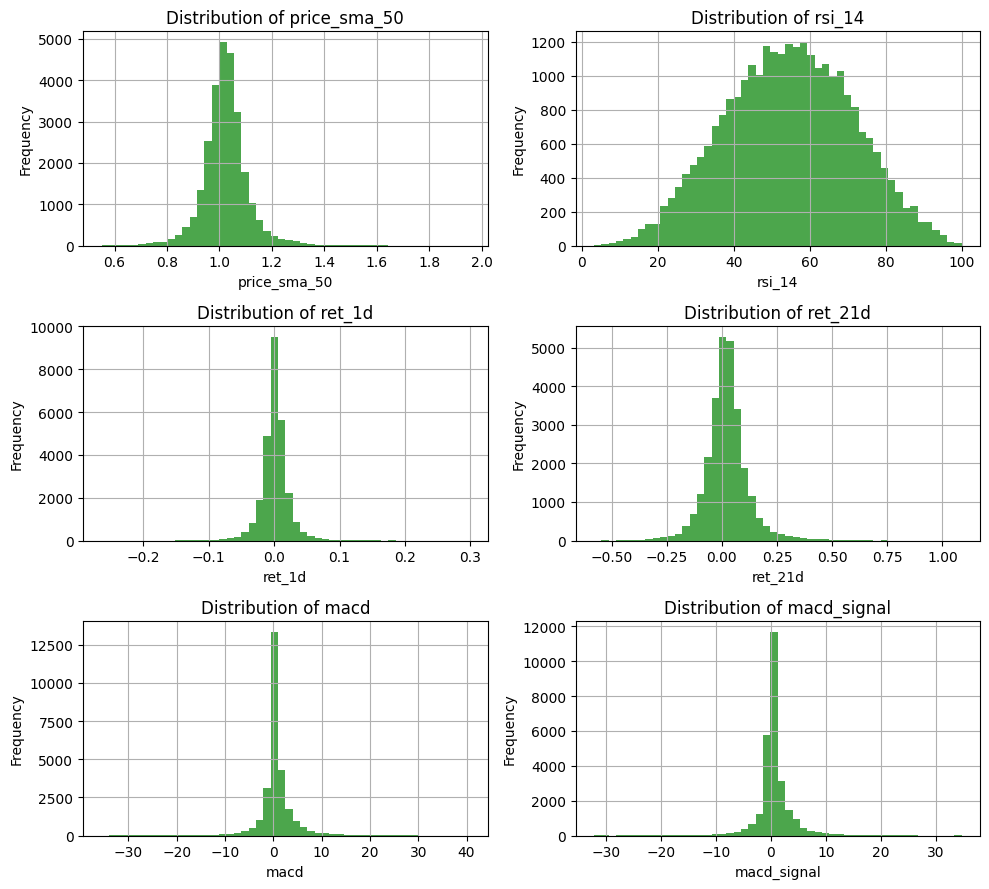

In [71]:
# technical distributions (2 plots per row, smaller)
interesting_cols = [
    "price_sma_200",
    "mom_3m",
    "mom_6m",
    "mom_12m",
    "volatility_20d",
    "volatility_60d",
    "ret_1d",
    "ret_21d",
]
interesting_cols = [c for c in interesting_cols if c in df_raw.columns]

n = len(interesting_cols)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(10, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(interesting_cols):
    ax = axes[i]
    ax.hist(df_raw[col].dropna(), bins=50, color='green', alpha=0.7)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.grid(True)

# turn off any unused subplots
for j in range(n, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


We visualize a small subset of technical features that are informative about preprocessing decisions:

- **Normalized ratios** (e.g., `price_sma_200`) should be centered and stable across assets.
- **Momentum features** (`mom_3m/6m/12m`) should have symmetric heavy tails but plausible ranges.
- **Volatility** should be strictly non-negative and higher in the tails.
- **Returns** show heavy tails but should not be clipped in preprocessing.


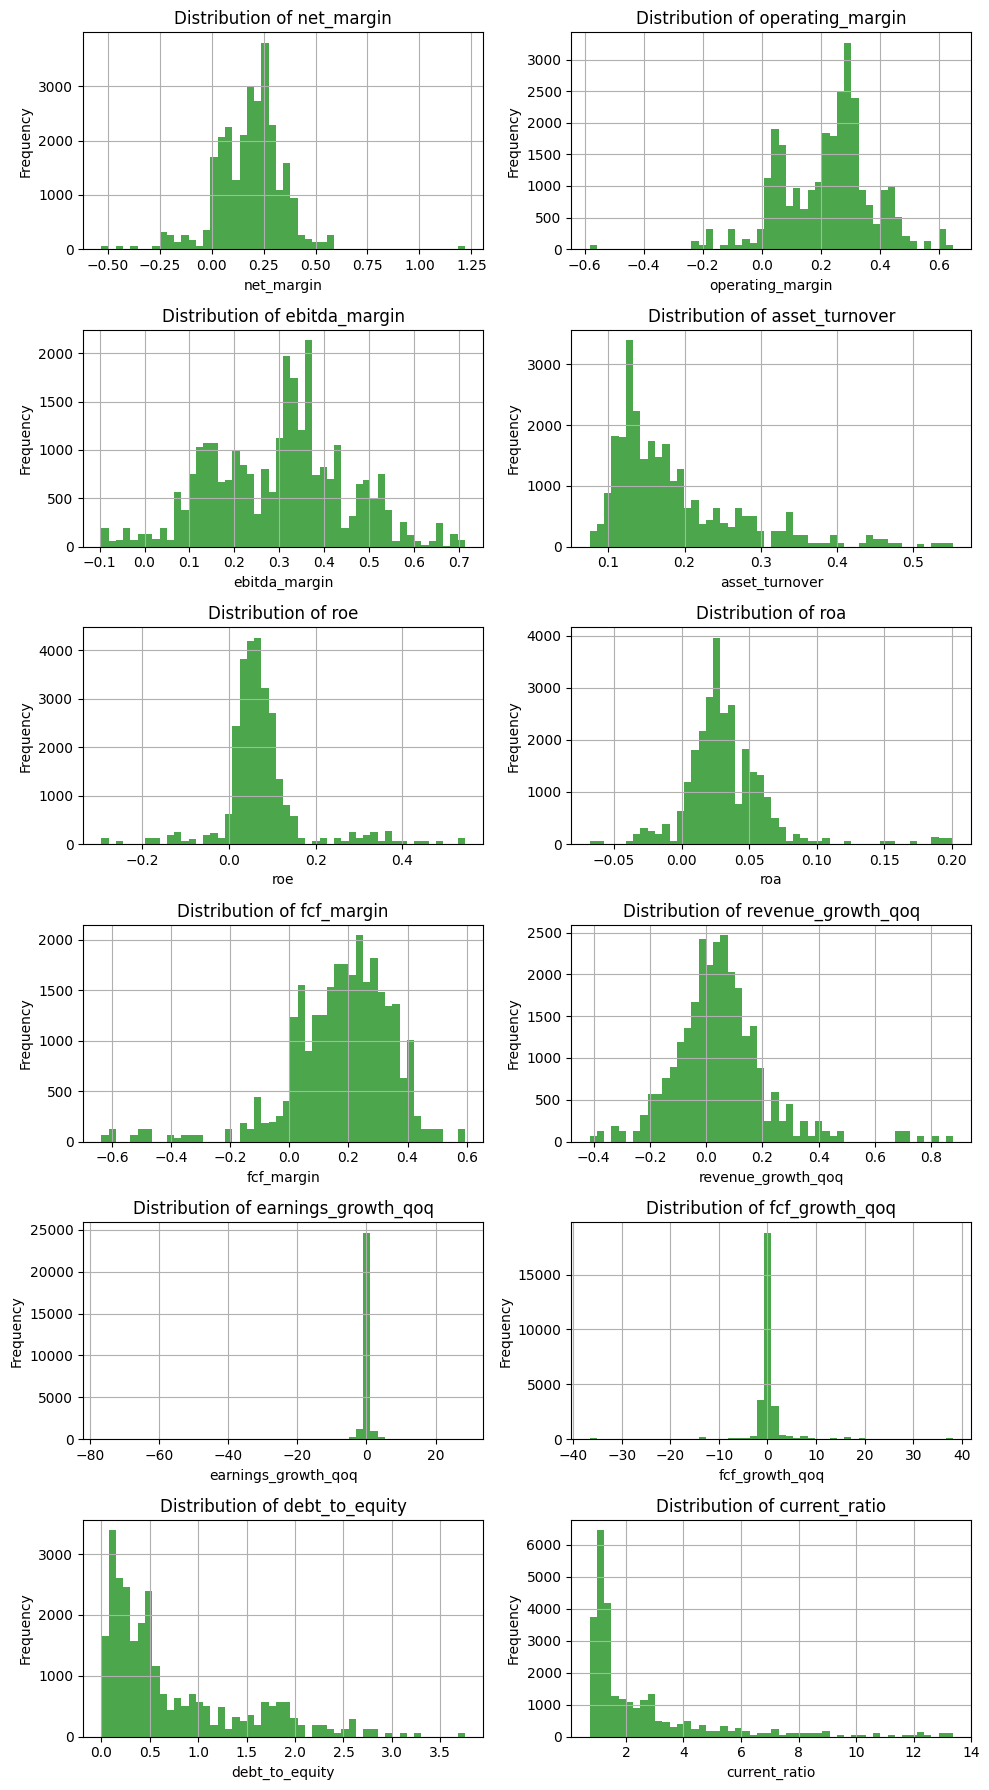

In [68]:
# fundamental distributions (2 plots per row, smaller)
n = len(fund_cols)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(10, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(fund_cols):
    ax = axes[i]
    ax.hist(df_raw[col].dropna(), bins=50, color='green', alpha=0.7)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.grid(True)

# turn off any unused subplots
for j in range(n, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Fundamental variables often exhibit outliers due to accounting effects, small denominators, and non-recurring events.
This section visualizes the most critical fundamentals to justify **domain-based clipping** and/or **cross-sectional winsorization**:

- margins (potential extreme values outside plausible bounds),
- ROE (instability when equity is small),
- growth rates (base effects leading to extreme values),
- leverage ratios (long right tails).

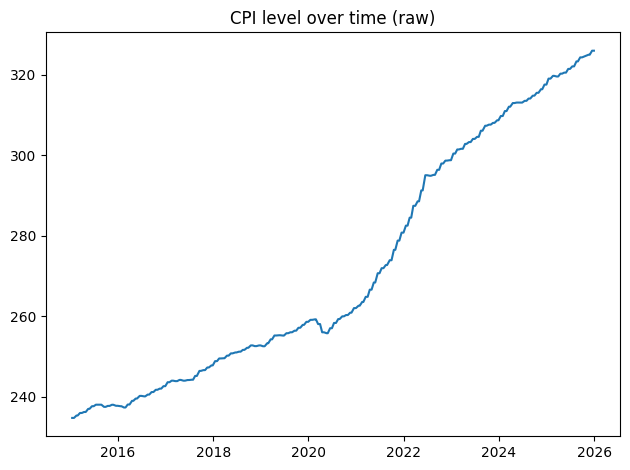

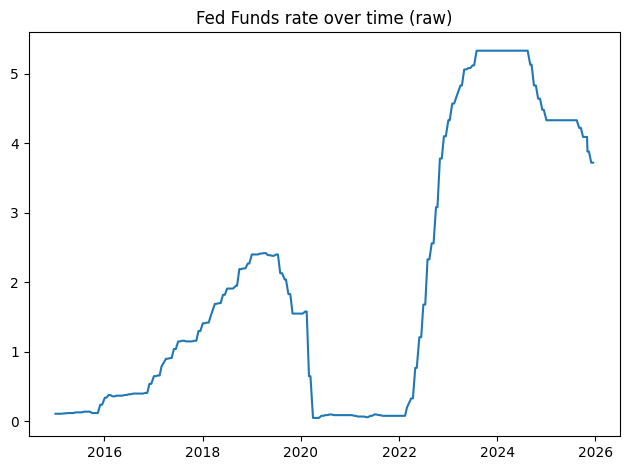

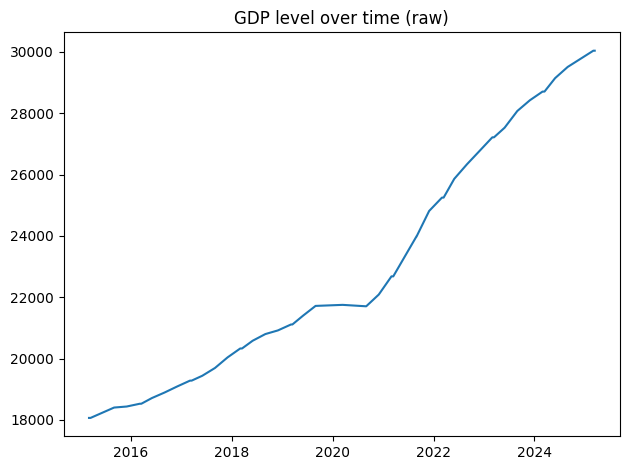

In [65]:
def line_plot(df, x_col, y_col, title):
    plt.figure()
    tmp = df[[x_col, y_col]].dropna().sort_values(x_col)
    plt.plot(tmp[x_col], tmp[y_col])
    plt.title(title)
    plt.tight_layout()
    plt.show()

ticker0 = df_raw["ticker"].iloc[0]
tmp_macro = df_raw[df_raw["ticker"] == ticker0].copy()

line_plot(tmp_macro, "date", "CPIAUCSL", "CPI level over time (raw)")
line_plot(tmp_macro, "date", "FEDFUNDS", "Fed Funds rate over time (raw)")
line_plot(tmp_macro, "date", "GDP", "GDP level over time (raw)")

Macroeconomic series are official, smooth signals with no abnormal outliers.
The main issue is their lower publication frequency, which creates structurally missing values in a daily panel.
We therefore visualize them over time to emphasize smooth dynamics.


## Potential Problems

Based on the summary statistics, we identify the main distributional issues affecting the dataset.

### Overall NaN Rate

A high NaN rate can indicate misaligned joins or sparse macro releases. Macro series update monthly/quarterly, so after the merge many dates inherit NaNs; we must forward-fill or align to release dates in preprocessing to avoid losing large portions of data. As for the other columns with NaN vaues, we assume this is perfectly normal, as all of them are rolling features.

In [31]:
nan_rate = df_raw.isna().mean().sort_values(ascending=False)
display(nan_rate.head(15))


GDP               0.948282
FEDFUNDS          0.528752
CPIAUCSL          0.511392
sma_200           0.072333
price_sma_50      0.018083
sma_50            0.018083
debt_to_equity    0.015949
ret_21d           0.007957
volatility_20d    0.007595
rsi_14            0.005425
ret_5d            0.002170
ret_1d            0.000723
macd              0.000362
macd_signal       0.000362
ema_20            0.000362
dtype: float64

### Volume Distribution

Raw volume is highly skewed with extreme spikes. This can dominate model loss and distort scaling, so we typically apply a log transform (e.g., log1p) or robust scaling before training.

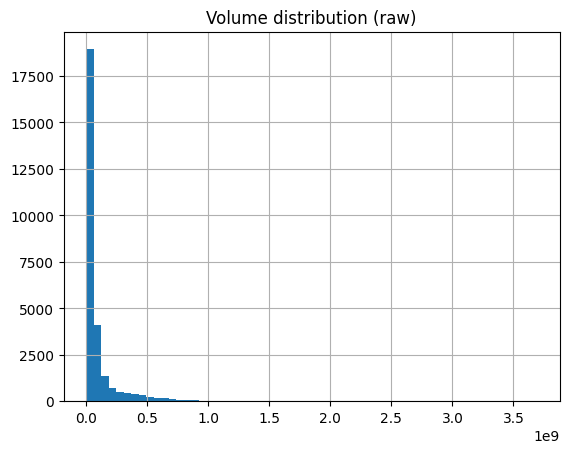

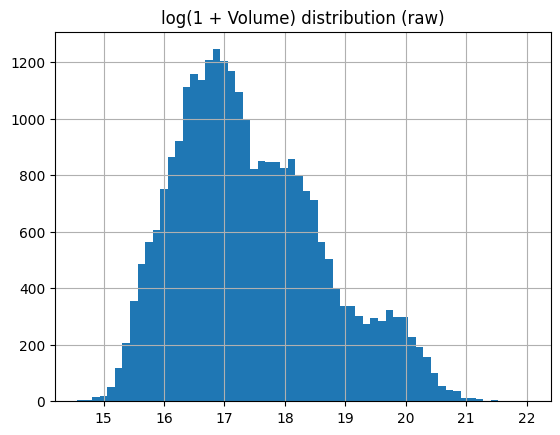

In [32]:
plt.figure()
df_raw["volume"].dropna().hist(bins=60)
plt.title("Volume distribution (raw)")
plt.show()

plt.figure()
np.log1p(df_raw["volume"].dropna()).hist(bins=60)
plt.title("log(1 + Volume) distribution (raw)")
plt.show()


### Outliers in Fundamental Features

Unlike market-based variables, fundamental ratios are derived from accounting data and are therefore more prone to extreme values.
Outliers in this context often arise from:
- small or negative denominators (e.g. equity or earnings close to zero),
- non-recurring accounting events,
- base effects in growth rates.

As shown by the distributional statistics and boxplots, several fundamental variables exhibit heavy tails and values that exceed economically plausible bounds.
These extreme observations do not represent persistent firm characteristics and may disproportionately influence cross-sectional ranking models.

For this reason, domain-aware clipping and cross-sectional winsorization are applied during preprocessing to stabilize fundamental features while preserving relative information across firms.

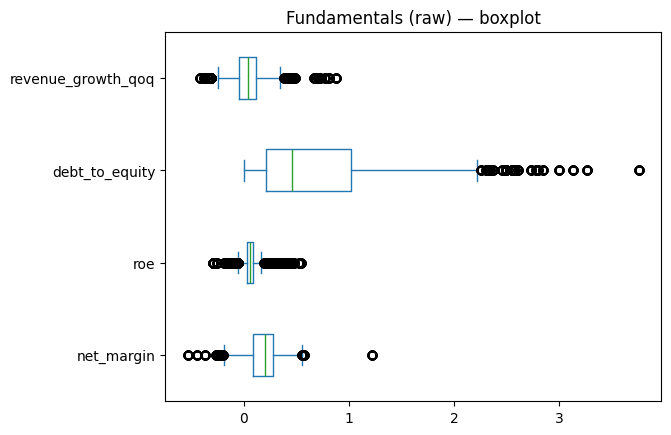

In [75]:
cols_box = ["operating_margin", "roe", "debt_to_equity", "revenue_growth_yoy", "delta_roe_yoy"]
cols_box = [c for c in cols_box if c in df_raw.columns]
if cols_box:
    df_raw[cols_box].plot(kind="box", vert=False)
    plt.title("Fundamentals (raw) — boxplot")
    plt.show()
else:
    print("No fundamental columns found for boxplot.")


## Preprocessing

Based on the issues identified above, we apply a preprocessing step that stabilizes fundamental variables and propagates macroeconomic information forward in time. No standardization is applied at this stage, as scaling choices are model-dependent and deferred to the modeling phase.
The preprocessing logic is implemented as a reusable function and is applied to the raw dataset using the configuration defined below.

### Importing the function

Function is imported from `REPO_ROOT/src/preprocessing/preprocessing.py`

In [72]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
  
from src.preprocessing.preprocessing import preprocess_daily_panel, PreprocessConfig


### Config and Run

Choosing the right configuration for the preprocess is fundamental. For this reason we have the `PreprocessConfig` class, where parameters such as columns and the minimum non-NaN ratio can be indicated.

In [73]:
cfg = PreprocessConfig(
    macro_cols=macro_cols,
    growth_cols=["revenue_growth_yoy", "earnings_growth_yoy"],
    margin_cols=["operating_margin", "gross_margin"],
    fundamental_cols=[
        "operating_margin",
        "gross_margin",
        "roe",
        "roa",
        "asset_turnover",
        "debt_to_equity",
        "interest_coverage",
        "revenue_growth_yoy",
        "earnings_growth_yoy",
        "fcf_assets",
        "delta_roe_yoy",
    ],
    min_non_na_ratio=0.90,
)

df_prep = preprocess_daily_panel(df_raw, config=cfg)

print("Raw shape:", df_raw.shape)
print("Prep shape:", df_prep.shape)


Raw shape: (27650, 36)
Prep shape: (27650, 37)


/Users/igordragone/projects/hybrid-stock-prediction-thesis/src/preprocessing/preprocessing.py:177: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = out.groupby(date_col, group_keys=False).apply(_clip_group)


,date,open,high,low,close,adj_close,volume,sma_50,sma_200,ema_20,price_sma_50,rsi_14,macd,macd_signal,volatility_20d,ret_1d,ret_5d,ret_21d,net_margin,operating_margin,ebitda_margin,asset_turnover,roe,roa,fcf_margin,revenue_growth_qoq,earnings_growth_qoq,fcf_growth_qoq,debt_to_equity,current_ratio,effective_date,macro_effective_date,CPIAUCSL,FEDFUNDS,GDP,ticker,log_volume
0,2015-01-02,27.847500,27.860001,26.837500,27.332500,24.237553,212818400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.201007,0.265057,0.321819,0.181691,0.074765,0.036470,0.223109,0.123996,0.092798,0.201176,0.316414,1.012057,2014-11-29,2015-01-01,NaN,0.11,NaN,AAPL,19.175950
1,2015-01-02,15.629000,15.737500,15.348000,15.426000,15.426000,55664000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.021235,-0.026435,0.027455,0.489650,-0.042279,-0.010812,0.018854,0.064064,2.000000,-0.500000,0.383417,0.891085,2014-11-29,2015-01-01,NaN,0.11,NaN,AMZN,17.834844
2,2015-01-02,26.629999,26.790001,26.393999,26.477501,26.278944,26480000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.165769,0.225383,0.328572,0.131363,0.027718,0.021776,0.216486,0.035600,-0.182632,0.199933,0.053018,4.470703,2014-11-29,2015-01-01,NaN,0.11,NaN,GOOGL,17.091900


## Results

After preprocessing, we reassess missing values and distributions to verify that the identified issues have been resolved.
This validation ensures that the dataset is stable and suitable for subsequent feature engineering.

### Nan Rate

We first re-evaluate the proportion of missing values across all features.
Remaining NaNs are expected and primarily associated with rolling technical indicators during their initial warm-up periods.
No additional imputation is performed at this stage.

In [77]:
nan_rate_prep = df_prep.isna().mean().sort_values(ascending=False)
display(nan_rate_prep.head(15))

sma_200           0.072333
sma_50            0.018083
price_sma_50      0.018083
debt_to_equity    0.015949
GDP               0.014105
ret_21d           0.007957
volatility_20d    0.007595
rsi_14            0.005425
CPIAUCSL          0.003617
ret_5d            0.002170
ret_1d            0.000723
macd_signal       0.000362
macd              0.000362
ema_20            0.000362
current_ratio     0.000000
dtype: float64

In [78]:
print("Macro NaN (raw):")
display(df_raw[macro_cols].isna().mean())

print("\nMacro NaN (prep):")
display(df_prep[macro_cols].isna().mean())

Macro NaN (raw):


CPIAUCSL    0.511392
FEDFUNDS    0.528752
GDP         0.948282
dtype: float64


Macro NaN (prep):


CPIAUCSL    0.003617
FEDFUNDS    0.000000
GDP         0.014105
dtype: float64

After forward propagation, macroeconomic variables exhibit a negligible proportion of missing values.
Residual NaNs are confined to the initial part of the sample, before the first historical release, and are therefore structurally unavoidable.

### Fundamental Outliers

We reassess the statistics of fundamental variables after applying domain-based clipping and winsorization.
Extreme values observed in the raw data are substantially reduced, while the central mass and relative ordering of firms are preserved.
This confirms the effectiveness of the stabilization step.

In [79]:
desc_raw = df_raw[fund_cols].describe(percentiles=[.01, .05, .5, .95, .99]).T
desc_prep = df_prep[fund_cols].describe(percentiles=[.01, .05, .5, .95, .99]).T

print("RAW percentiles:")
display(desc_raw[["min", "1%", "5%", "50%", "95%", "99%", "max"]])

print("\nPREP percentiles:")
display(desc_prep[["min", "1%", "5%", "50%", "95%", "99%", "max"]])

RAW percentiles:


,min,1%,5%,50%,95%,99%,max
net_margin,-0.530478,-0.246081,-0.061304,0.200593,0.391108,0.555807,1.219053
operating_margin,-0.583956,-0.187431,-0.013099,0.249545,0.449013,0.611070,0.649247
ebitda_margin,-0.096024,-0.053023,0.075363,0.318766,0.535671,0.656505,0.712876
asset_turnover,0.075510,0.085465,0.103167,0.160045,0.352470,0.476508,0.552103
roe,-0.294227,-0.178075,-0.037166,0.062650,0.285844,0.434208,0.544204
roa,-0.068104,-0.030709,-0.010812,0.028223,0.074811,0.187736,0.201108
fcf_margin,-0.635941,-0.495193,-0.113687,0.196607,0.413311,0.479277,0.594322
revenue_growth_qoq,-0.414572,-0.324884,-0.185162,0.041032,0.307499,0.705152,0.878059
earnings_growth_qoq,-76.647059,-3.846174,-1.074621,0.038690,1.287507,5.101266,28.514706
fcf_growth_qoq,-36.603448,-7.416172,-1.658919,-0.048683,2.452261,16.303797,38.220588



PREP percentiles:


,min,1%,5%,50%,95%,99%,max
net_margin,-0.515706,-0.234413,-0.052061,0.200593,0.387901,0.537704,1.000000
operating_margin,-0.526584,-0.170503,-0.007160,0.249545,0.447564,0.599533,0.630944
ebitda_margin,-0.080599,-0.038380,0.075363,0.318766,0.532259,0.648103,0.707803
asset_turnover,0.076750,0.088472,0.103784,0.160045,0.352425,0.450146,0.525696
roe,-0.266282,-0.170333,-0.032917,0.062650,0.285844,0.405815,0.521597
roa,-0.064793,-0.027587,-0.010333,0.028223,0.074811,0.178720,0.192511
fcf_margin,-0.574907,-0.455253,-0.105477,0.196607,0.405944,0.472653,0.570936
revenue_growth_qoq,-0.392443,-0.312161,-0.183512,0.041032,0.305892,0.657968,0.809572
earnings_growth_qoq,-0.500000,-0.500000,-0.500000,0.038690,1.265387,2.000000,2.000000
fcf_growth_qoq,-0.500000,-0.500000,-0.500000,-0.048683,2.000000,2.000000,2.000000


After preprocessing, summary statistics remain largely unchanged across central percentiles, while extreme values are substantially reduced. This confirms that the preprocessing step stabilizes outliers without altering the core distribution or relative ordering of firms. The best example of this behaviour are growth features.


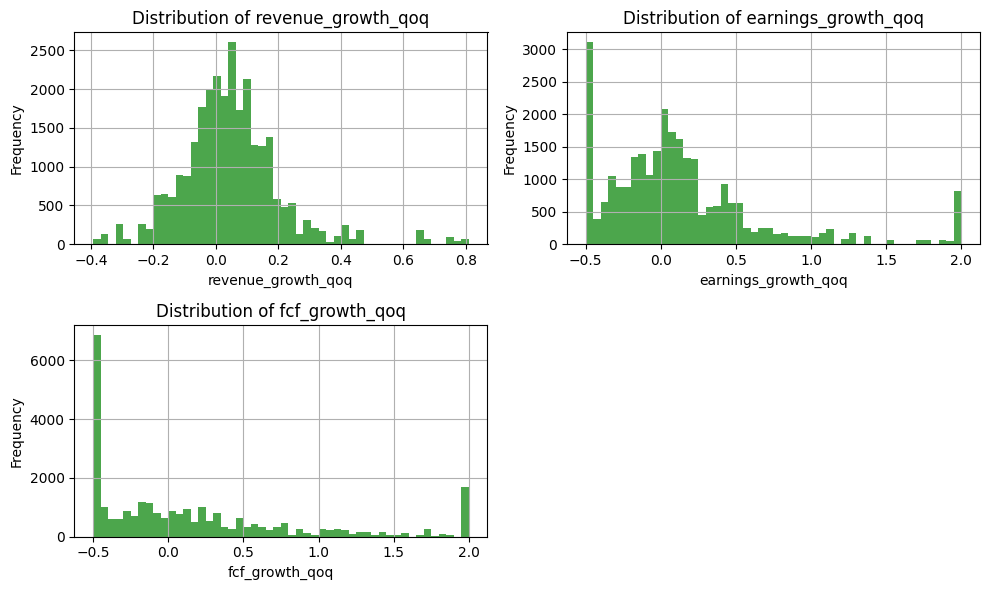

In [85]:
growth_cols = ["revenue_growth_yoy", "earnings_growth_yoy"]

growth_cols = [c for c in growth_cols if c in df_prep.columns]

n = len(growth_cols)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(10, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(growth_cols):
    ax = axes[i]
    ax.hist(df_prep[col].dropna(), bins=50, color='green', alpha=0.7)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.grid(True)

# turn off any unused subplots
for j in range(n, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


### Quick check

As a final verification, we inspect selected variables for a single representative stock, where the new feature `log_volume`is present and macroeconomic variables remain constant between releases.

In [82]:
ticker = "AAPL"
cols_show = ["date", "ticker", "log_volume", "CPIAUCSL", "FEDFUNDS", "GDP"]

tmp = df_prep[df_prep["ticker"] == ticker].sort_values("date")
display(tmp[cols_show].tail(20))

,date,ticker,log_volume,CPIAUCSL,FEDFUNDS,GDP
27450,2025-12-02,AAPL,17.798355,325.031,3.72,30042.113
27460,2025-12-03,AAPL,17.589161,325.031,3.72,30042.113
27470,2025-12-04,AAPL,17.599452,325.031,3.72,30042.113
27480,2025-12-05,AAPL,17.671298,325.031,3.72,30042.113
27490,2025-12-08,AAPL,17.458655,325.031,3.72,30042.113
27500,2025-12-09,AAPL,17.287269,325.031,3.72,30042.113
27510,2025-12-10,AAPL,17.313178,325.031,3.72,30042.113
27520,2025-12-11,AAPL,17.319505,325.031,3.72,30042.113
27530,2025-12-12,AAPL,17.492644,325.031,3.72,30042.113
27540,2025-12-15,AAPL,17.735682,325.031,3.72,30042.113


## Saving The File

The preprocessed dataset is saved as a separate Parquet file.
This ensures a clear separation between preprocessing, feature engineering, and target construction, and allows downstream steps to be reproduced without re-running earlier stages.

In [76]:
df_prep.to_parquet(OUT_PREP_PATH, index=False)
print("Saved:", OUT_PREP_PATH)

Saved: ../data/processed/financial_database_preprocessed.parquet
